الف) بارگذاری و پیش‌پردازش داده‌ها


In [32]:
# ======================================
# الف) بارگذاری و پیش‌پردازش داده
# ======================================

!gdown 1G5oS1nhnQIoK24rEjf9oMiUw2zr4ZoY9  # دانلود داده

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# بارگذاری داده
df = pd.read_csv('Mall_Customers.csv')

# انتخاب ویژگی‌های عددی
numeric_features = df.select_dtypes(include=[np.number]).columns
X = df[numeric_features]

# استانداردسازی
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA دوبعدی برای نمایش
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)

print(f"✓ داده بارگذاری شد - شکل: {X.shape}")
print(f"✓ استانداردسازی انجام شد")

Downloading...
From: https://drive.google.com/uc?id=1G5oS1nhnQIoK24rEjf9oMiUw2zr4ZoY9
To: /content/Mall_Customers.csv
100% 3.98k/3.98k [00:00<00:00, 13.5MB/s]
✓ داده بارگذاری شد - شکل: (200, 4)
✓ استانداردسازی انجام شد


In [33]:
# ======================================
# ب) KMeans با K ∈ {2,...,10}
# ======================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results_kmeans = {}
silhouette_scores = []
inertia_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=5, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, labels)
    inertia = kmeans.inertia_

    results_kmeans[k] = {
        'model': kmeans,
        'labels': labels,
        'silhouette': sil_score,
        'inertia': inertia
    }

    silhouette_scores.append(sil_score)
    inertia_scores.append(inertia)

    print(f"K={k:2d} | Silhouette: {sil_score:.4f} | Inertia: {inertia:.2f}")

# انتخاب بهترین K
best_k = list(results_kmeans.keys())[np.argmax(silhouette_scores)]
print(f"\n✓ بهترین K: {best_k}")

K= 2 | Silhouette: 0.3185 | Inertia: 515.67
K= 3 | Silhouette: 0.3363 | Inertia: 375.26
K= 4 | Silhouette: 0.4136 | Inertia: 259.71
K= 5 | Silhouette: 0.4272 | Inertia: 209.58
K= 6 | Silhouette: 0.4390 | Inertia: 160.98
K= 7 | Silhouette: 0.4193 | Inertia: 144.67
K= 8 | Silhouette: 0.3990 | Inertia: 130.59
K= 9 | Silhouette: 0.3771 | Inertia: 116.21
K=10 | Silhouette: 0.3788 | Inertia: 104.39

✓ بهترین K: 6


SINGLE     | Silhouette: -0.0451
COMPLETE   | Silhouette: 0.3917
AVERAGE    | Silhouette: 0.4302
WARD       | Silhouette: 0.4283


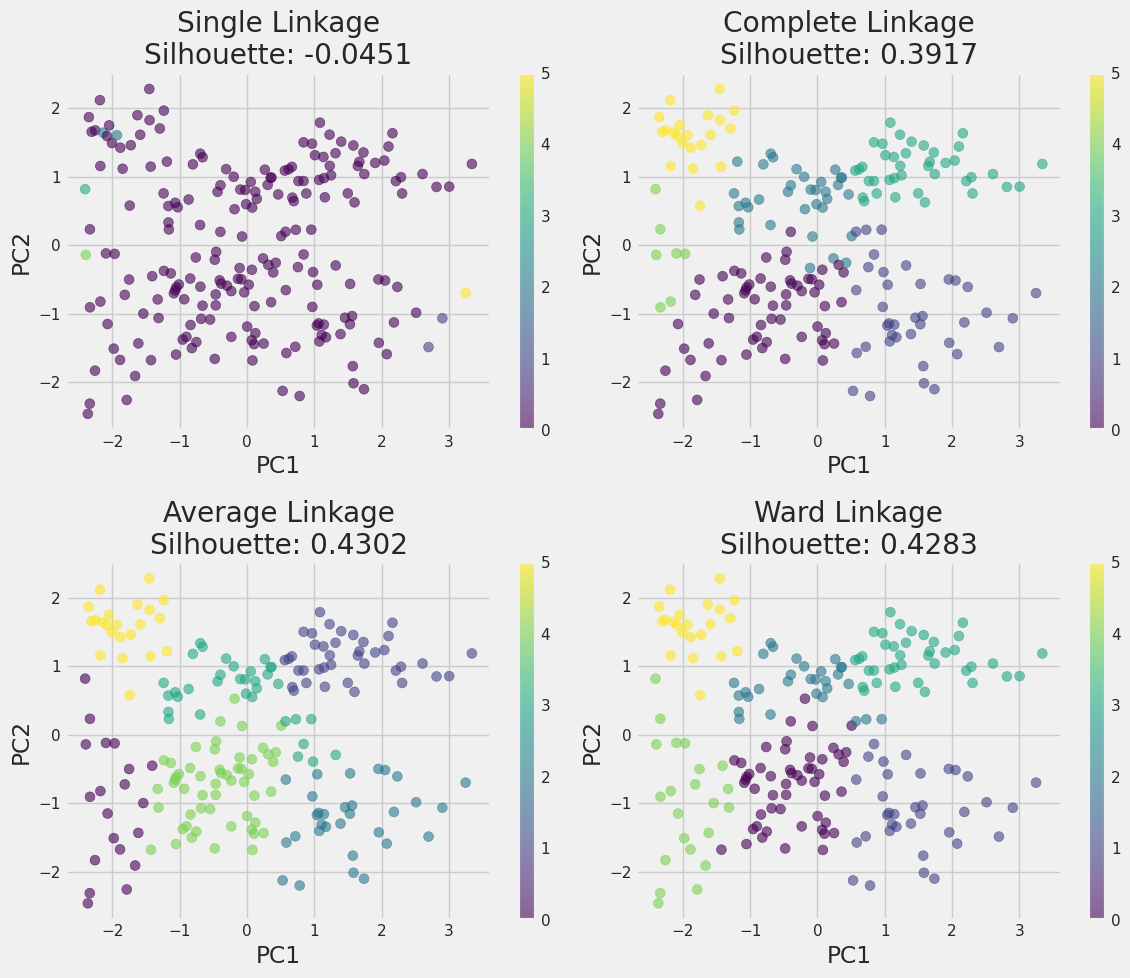


✓ بهترین linkage: average


In [34]:
# ======================================
# ج) Agglomerative Clustering
# ======================================

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

linkage_methods = ['single', 'complete', 'average', 'ward']
results_agg = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, linkage in enumerate(linkage_methods):
    # استفاده از بهترین K از KMeans
    agg_clustering = AgglomerativeClustering(
        n_clusters=best_k,
        linkage=linkage
    )
    labels = agg_clustering.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, labels)

    results_agg[linkage] = {
        'model': agg_clustering,
        'labels': labels,
        'silhouette': sil_score
    }

    # رسم
    scatter = axes[idx].scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                                c=labels, cmap='viridis', s=50, alpha=0.6)
    axes[idx].set_title(f'{linkage.capitalize()} Linkage\nSilhouette: {sil_score:.4f}')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    plt.colorbar(scatter, ax=axes[idx])

    print(f"{linkage.upper():10s} | Silhouette: {sil_score:.4f}")

plt.tight_layout()
plt.savefig('agglomerative_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# بهترین روش
best_linkage = max(results_agg, key=lambda x: results_agg[x]['silhouette'])
print(f"\n✓ بهترین linkage: {best_linkage}")

ε=0.2, min_samples= 3 | Clusters:  4 | Noise: 187 | Silhouette: 0.8587
ε=0.4, min_samples= 3 | Clusters: 13 | Noise:  76 | Silhouette: 0.4007
ε=0.6, min_samples= 3 | Clusters:  5 | Noise:  18 | Silhouette: 0.2258
ε=0.8, min_samples= 3 | Clusters:  1 | Noise:   3 | Silhouette: -1.0000
ε=1.0, min_samples= 3 | Clusters:  1 | Noise:   2 | Silhouette: -1.0000
ε=0.2, min_samples= 5 | Clusters:  0 | Noise: 200 | Silhouette: -1.0000
ε=0.4, min_samples= 5 | Clusters:  9 | Noise: 119 | Silhouette: 0.5177
ε=0.6, min_samples= 5 | Clusters:  7 | Noise:  38 | Silhouette: 0.3789
ε=0.8, min_samples= 5 | Clusters:  1 | Noise:   7 | Silhouette: -1.0000
ε=1.0, min_samples= 5 | Clusters:  1 | Noise:   2 | Silhouette: -1.0000
ε=0.2, min_samples=10 | Clusters:  0 | Noise: 200 | Silhouette: -1.0000
ε=0.4, min_samples=10 | Clusters:  1 | Noise: 190 | Silhouette: -1.0000
ε=0.6, min_samples=10 | Clusters:  5 | Noise:  92 | Silhouette: 0.5123
ε=0.8, min_samples=10 | Clusters:  2 | Noise:  28 | Silhouette: 0.2614

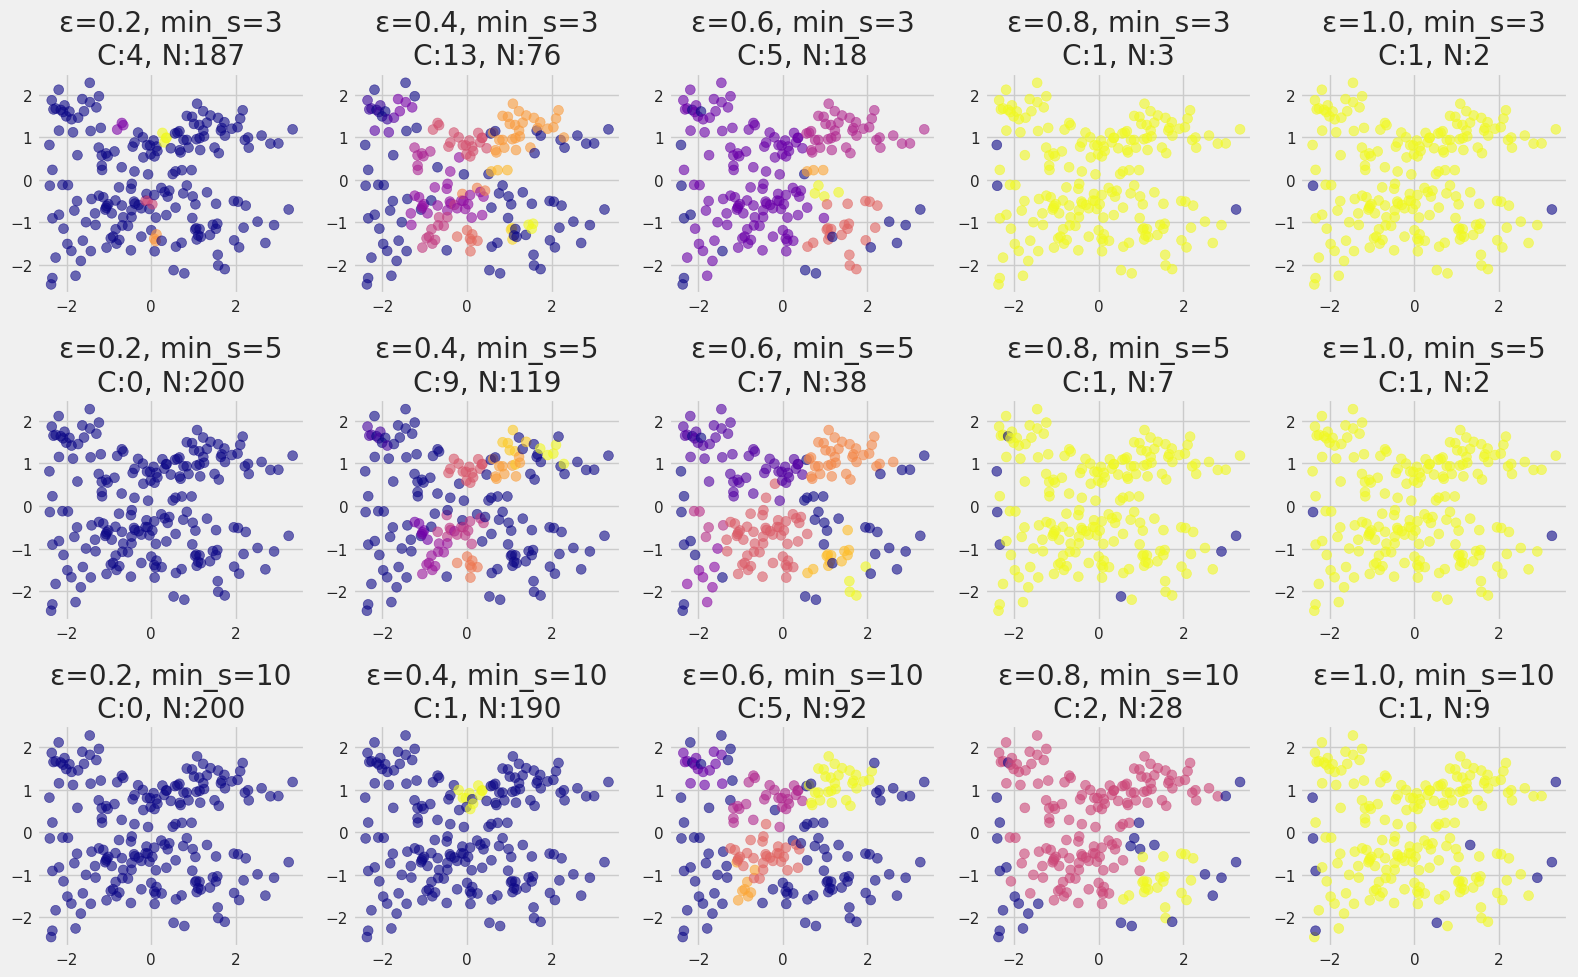

In [35]:
# ======================================
# د) DBSCAN با پارامترهای مختلف
# ======================================

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

eps_values = [0.2, 0.4, 0.6, 0.8, 1.0]
min_samples_values = [3, 5, 10]

results_dbscan = {}
fig, axes = plt.subplots(3, 5, figsize=(16, 10))

for i, min_samples in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            sil_score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        else:
            sil_score = -1

        results_dbscan[f'eps{eps}_min{min_samples}'] = {
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        }

        # رسم
        scatter = axes[i, j].scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                                     c=labels, cmap='plasma', s=50, alpha=0.6)
        axes[i, j].set_title(f'ε={eps}, min_s={min_samples}\nC:{n_clusters}, N:{n_noise}')

        print(f"ε={eps:.1f}, min_samples={min_samples:2d} | "
              f"Clusters: {n_clusters:2d} | Noise: {n_noise:3d} | "
              f"Silhouette: {sil_score:.4f}")

plt.tight_layout()
plt.savefig('dbscan_results.png', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


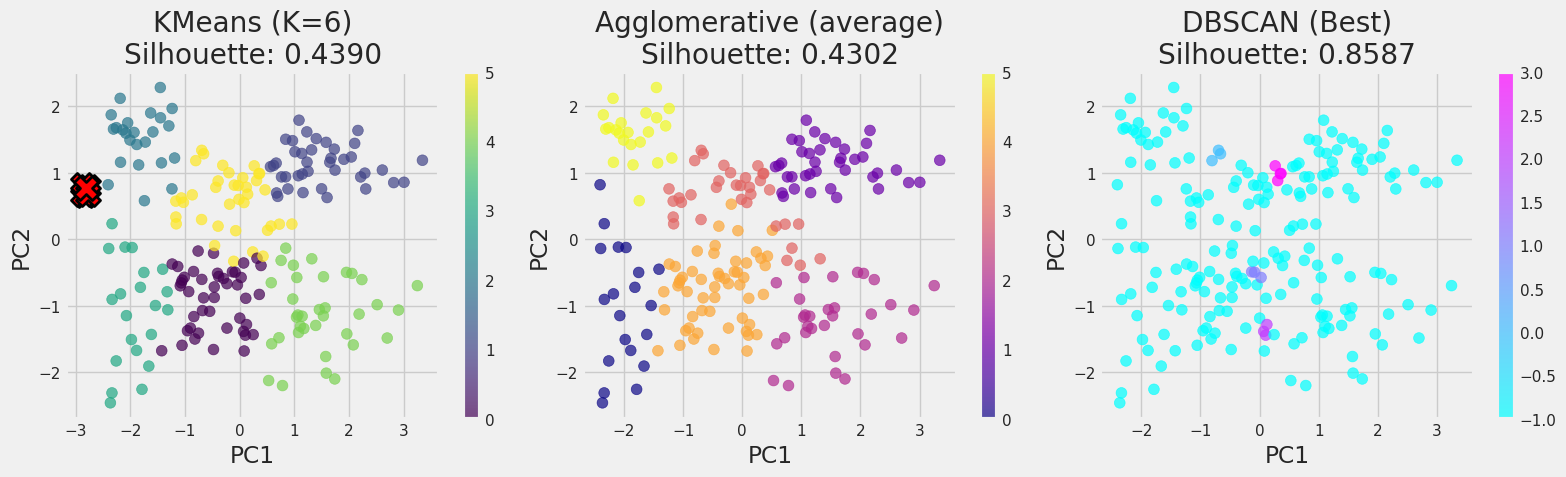


خلاصه نتایج نهایی
بهترین KMeans: K=6
بهترین Agglomerative: average
بهترین DBSCAN: eps0.2_min3


In [36]:
# ======================================
# ه) تجزیه و تحلیل نهایی در فضای PCA
# ======================================

# انتخاب بهترین مدل از هر روش
best_kmeans_model = results_kmeans[best_k]['model']
best_agg_model = results_agg[best_linkage]['model']

# رسم مقایسه‌ای نهایی
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# KMeans
scatter1 = axes[0].scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                           c=best_kmeans_model.labels_, cmap='viridis', s=60, alpha=0.7)
axes[0].scatter(pca_viz.transform(scaler.transform(best_kmeans_model.cluster_centers_))[:, 0],
                pca_viz.transform(scaler.transform(best_kmeans_model.cluster_centers_))[:, 1],
                c='red', marker='X', s=300, edgecolors='black', linewidths=2)
axes[0].set_title(f'KMeans (K={best_k})\nSilhouette: {results_kmeans[best_k]["silhouette"]:.4f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# Agglomerative
scatter2 = axes[1].scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                           c=best_agg_model.labels_, cmap='plasma', s=60, alpha=0.7)
axes[1].set_title(f'Agglomerative ({best_linkage})\nSilhouette: {results_agg[best_linkage]["silhouette"]:.4f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# DBSCAN (بهترین)
best_dbscan_key = max(results_dbscan, key=lambda x: results_dbscan[x]['silhouette'])
best_dbscan_labels = results_dbscan[best_dbscan_key]['labels']
scatter3 = axes[2].scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                           c=best_dbscan_labels, cmap='cool', s=60, alpha=0.7)
axes[2].set_title(f'DBSCAN (Best)\nSilhouette: {results_dbscan[best_dbscan_key]["silhouette"]:.4f}')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("خلاصه نتایج نهایی")
print("="*60)
print(f"بهترین KMeans: K={best_k}")
print(f"بهترین Agglomerative: {best_linkage}")
print(f"بهترین DBSCAN: {best_dbscan_key}")

In [37]:
# ======================================
# اصل تکراپذیری - random_state = 05
# ======================================

# تنظیم random_state در تمام جاهایی که استفاده شد:
# - KMeans: random_state=5
# - PCA: random_state=5
# - DBSCAN و AgglomerativeClustering (deterministic هستند)

print("\n✓ تمام مدل‌ها با random_state=05  تنظیم شدند")


✓ تمام مدل‌ها با random_state=05  تنظیم شدند
